In [1]:
import numpy as np
import pandas as pd
import warnings
import graphviz
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn import datasets
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import  train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score

In [2]:
df = pd.read_excel(r"aoao_educate_data.xlsx",sheet_name="ВСЕ ИМЕНА")

In [3]:
df

,ФИО,Пол,Лактат,Глюкоза,Общий белок,Мочевина,Холестерин,ПОЛ в плазме,ПОЛ в мембр. эритроцитов,Кортизол,Зонулин,ЭХ,ТГ,НеЖК,ХЛ,ФЛ,Стадия
0,1,0,8.0,8.7,65.0,7.7,3.0,1.03,23.076923,369.000000,0.283000,31.490,39.335,48.950,17.420,21.750,2
1,2,0,6.8,6.0,85.6,7.7,3.0,2.05,30.769231,328.900000,0.370714,26.375,31.460,52.790,22.095,17.280,2
2,3,0,5.2,6.0,44.1,10.9,4.4,1.03,25.641026,235.230000,0.622000,31.815,50.050,23.250,24.020,20.850,2
3,4,1,8.4,5.6,41.5,8.9,4.6,1.53,35.897436,638.600000,0.322000,34.120,31.610,41.255,23.995,19.040,2
4,5,0,6.8,10.7,60.0,12.2,4.3,2.56,33.333333,384.540000,0.286000,32.535,39.405,25.420,24.810,27.840,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,58,1,6.0,4.8,60.0,5.6,5.5,1.03,28.205128,435.160000,0.292000,20.015,33.525,47.095,25.490,23.880,1
58,59,0,0.8,4.6,77.0,6.7,3.8,1.53,33.333333,235.416667,0.181000,29.730,33.690,45.050,23.640,15.430,0
59,60,0,11.2,8.0,62.2,6.4,1.5,1.03,30.769231,560.900000,0.261000,20.810,29.790,38.215,29.335,31.850,1
60,61,1,9.6,9.3,75.2,10.9,3.8,1.53,25.641026,222.420000,0.342000,23.380,33.145,40.490,27.865,24.670,1


In [4]:
x = df.drop("Стадия",axis=1)
y = df["Стадия"]


In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y)

In [6]:
clf = DecisionTreeClassifier(random_state = 42)
clf.fit(x_train, y_train)
prediction = clf.predict(x_test)
print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
print(f"Precision:{precision_score(y_test, prediction, average='weighted'):.3f}")
print(f"Recall:  {recall_score(y_test, prediction,average='weighted'):.3f}")
print(f"F1-score: {f1_score(y_test, prediction,average='weighted'):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

scores_f1 = cross_val_score(clf, x, y, cv=10, scoring='f1_weighted')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")

Accuracy:0.842
Precision:0.901
Recall:  0.842
F1-score: 0.826

Confusion Matrix:
 [[5 0 0 0]
 [0 2 0 0]
 [0 0 7 0]
 [3 0 0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      1.00      0.77         5
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         7
           3       1.00      0.40      0.57         5

    accuracy                           0.84        19
   macro avg       0.91      0.85      0.84        19
weighted avg       0.90      0.84      0.83        19

F1-результаты по фолдам: [0.42857143 1.         0.53968254 0.9        1.         0.46666667
 1.         1.         0.76666667 0.83333333]
Средний F1: 0.79


/home/ikuku/UDGU_project/UDGU_pr/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=10.
  warnings.warn(


In [7]:
clf = RandomForestClassifier(random_state = 42)
clf.fit(x_train, y_train)
prediction = clf.predict(x_test)
print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
print(f"Precision:{precision_score(y_test, prediction, average='weighted'):.3f}")
print(f"Recall:  {recall_score(y_test, prediction,average='weighted'):.3f}")
print(f"F1-score: {f1_score(y_test, prediction,average='weighted'):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

scores_f1 = cross_val_score(clf, x, y, cv=20, scoring='f1_weighted')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")

/home/ikuku/UDGU_project/UDGU_pr/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=20.
  warnings.warn(


Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000

Confusion Matrix:
 [[5 0 0 0]
 [0 2 0 0]
 [0 0 7 0]
 [0 0 0 5]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         2
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         5

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19

F1-результаты по фолдам: [0.65       1.         1.         1.         0.55555556 1.
 1.         0.55555556 1.         1.         0.55555556 1.
 1.         1.         1.         1.         1.         1.
 0.55555556 1.        ]
Средний F1: 0.89


In [8]:
from sklearn.ensemble import GradientBoostingClassifier

clf = GradientBoostingClassifier(
    random_state=42
)
clf.fit(x_train, y_train)
prediction = clf.predict(x_test)
print(f"Accuracy:{accuracy_score(y_test, prediction):.3f}")
print(f"Precision:{precision_score(y_test, prediction, average='weighted'):.3f}")
print(f"Recall:  {recall_score(y_test, prediction,average='weighted'):.3f}")
print(f"F1-score: {f1_score(y_test, prediction,average='weighted'):.3f}")
# print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, prediction))
print("\nClassification Report:\n", classification_report(y_test, prediction))

scores_f1 = cross_val_score(clf, x, y, cv=12, scoring='f1_weighted')

print(f"F1-результаты по фолдам: {scores_f1}")
print(f"Средний F1: {scores_f1.mean():.2f}")

Accuracy:0.895
Precision:0.895
Recall:  0.895
F1-score: 0.895

Confusion Matrix:
 [[5 0 0 0]
 [0 1 1 0]
 [0 1 6 0]
 [0 0 0 5]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       0.50      0.50      0.50         2
           2       0.86      0.86      0.86         7
           3       1.00      1.00      1.00         5

    accuracy                           0.89        19
   macro avg       0.84      0.84      0.84        19
weighted avg       0.89      0.89      0.89        19



/home/ikuku/UDGU_project/UDGU_pr/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 7 members, which is less than n_splits=12.
  warnings.warn(


F1-результаты по фолдам: [0.61111111 1.         1.         0.78666667 0.78666667 0.66666667
 1.         0.53333333 0.72       0.72       1.         1.        ]
Средний F1: 0.82


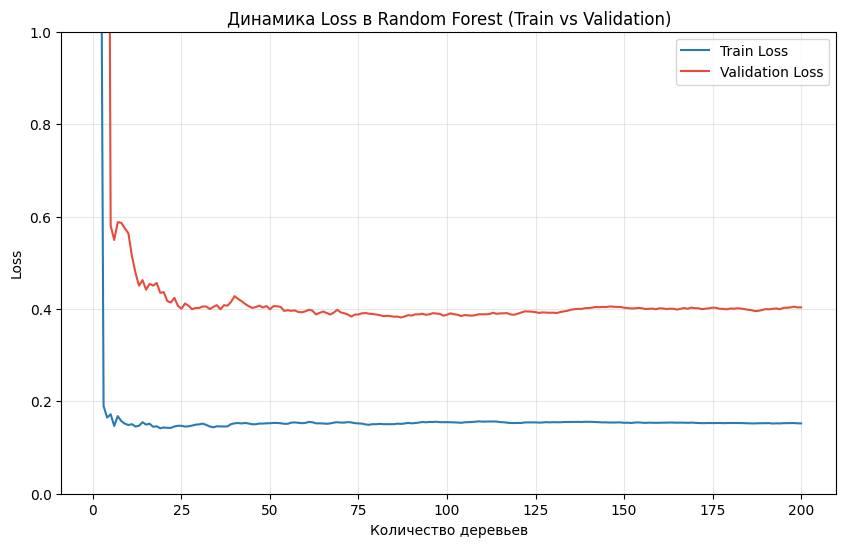

In [17]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
df = pd.read_excel("aoao_educate_data.xlsx",sheet_name="ВСЕ ИМЕНА")

x = df.drop("Стадия",axis=1)
y = df["Стадия"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)

# 1. Инициализация модели
# warm_start=True позволяет добавлять деревья, не обучая всё заново
clf = RandomForestClassifier(
max_depth=10,
warm_start=True
)

train_losses = []
val_losses = []
tree_counts = range(1, 201) # Пройдем от 1 до 100 деревьев

for i in tree_counts:
    clf.set_params(n_estimators=i)
    clf.fit(x_train, y_train)
    
    # Предсказываем вероятности для расчета Logloss
    train_proba = clf.predict_proba(x_train)
    val_proba = clf.predict_proba(x_test)
    
    train_losses.append(log_loss(y_train, train_proba))
    val_losses.append(log_loss(y_test, val_proba))

# 2. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(tree_counts, train_losses, label='Train Loss', color="#287bb3")
plt.plot(tree_counts, val_losses, label='Validation Loss', color='#e74c3c')

plt.title('Динамика Loss в Random Forest (Train vs Validation)')
plt.xlabel('Количество деревьев')
plt.ylabel('Loss')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()